In [2]:
import maboss
from matplotlib import pyplot as plt
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter
import seaborn as sns
from pathlib import Path
import numpy as np
from collections import OrderedDict
import ginsim
import biolqm

## Original PhysiBoSS TNF model

In [3]:
tnf_simple_bnd = "Boolean_network/cellfate.bnd"
tnf_simple_cfg = "Boolean_network/cellfate.cfg"

In [4]:
masim_tnf = maboss.load(tnf_simple_bnd, tnf_simple_cfg)

#list(masim_tnf.network.keys())

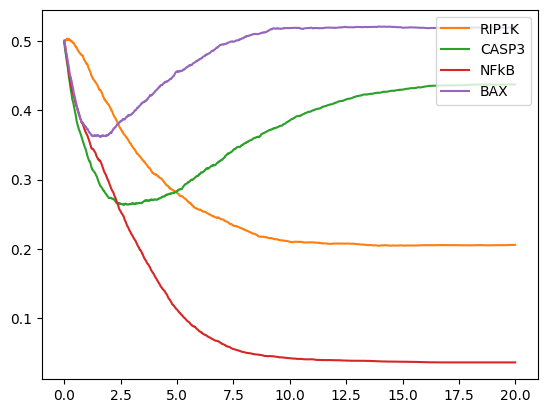

In [5]:
masim_tnf = maboss.load(tnf_simple_bnd, tnf_simple_cfg)

for node in list(masim_tnf.network.keys()):
    masim_tnf.network.set_istate(node, [0.5, 0.5])

masim_tnf.update_parameters(max_time=20, sample_count=10000)

masim_tnf.network.set_output(["BAX", "CASP3", "NFkB", "RIP1K"])

results_tnf = masim_tnf.run()

results_tnf.plot_node_trajectory()

In [6]:
for key, value in dict(results_tnf.get_last_states_probtraj()).items():
    print(key, value)

<nil> 19.9900    0.2748
Name: <nil>, dtype: float64
BAX 19.9900    0.0831
Name: BAX, dtype: float64
CASP3 19.9900    0.000684
Name: CASP3, dtype: float64
CASP3 -- BAX 19.9900    0.435716
Name: CASP3 -- BAX, dtype: float64
CASP3 -- RIP1K 19.9900    0.0007
Name: CASP3 -- RIP1K, dtype: float64
CASP3 -- RIP1K -- BAX 19.9900    0.0003
Name: CASP3 -- RIP1K -- BAX, dtype: float64
RIP1K 19.9900    0.1684
Name: RIP1K, dtype: float64
RIP1K -- BAX 19.9900    0.0005
Name: RIP1K -- BAX, dtype: float64
RIP1K -- NFkB 19.9900    0.0358
Name: RIP1K -- NFkB, dtype: float64


# Scenario 1 - MaBoSS model analysis

In [7]:
bnet_gpt5 = "Gpt_5/Scenario_1/Network_1.bnet"
bnet_sonnet4 = "Sonnet_4/Scenario_1/Network_1.bnet"
bnet_gpt_o4 = "Gpt_o4_mini/Scenario_1/Network_1.bnet"

In [8]:
bnd_gpt5 = "Gpt_5/Scenario_1/output.bnd"
cfg_gpt5 = "Gpt_5/Scenario_1/output.cfg"
bnd_sonnet4 = "Sonnet_4/Scenario_1/output.bnd"
cfg_sonnet4 = "Sonnet_4/Scenario_1/output.cfg"
bnd_gpt_o4 = "Gpt_o4_mini/Scenario_1/output.bnd"
cfg_gpt_o4 = "Gpt_o4_mini/Scenario_1/output.cfg"

In [9]:
masim_gpt5 = maboss.load(bnd_gpt5, cfg_gpt5)
masim_sonnet4 = maboss.load(bnd_sonnet4, cfg_sonnet4)
masim_gpt_o4 = maboss.load(bnd_gpt_o4, cfg_gpt_o4)

In [10]:
for node in list(masim_gpt5.network.keys()):
    masim_gpt5.network.set_istate(node, [0.5, 0.5])

for node in list(masim_sonnet4.network.keys()):
    masim_sonnet4.network.set_istate(node, [0.5, 0.5])

for node in list(masim_gpt_o4.network.keys()):
    masim_gpt_o4.network.set_istate(node, [0.5, 0.5])

In [11]:
masim_gpt5.network.set_output(["CCND1", "MYC", "CASP3", "BAX", "NFKB1"])

masim_gpt5.param["max_time"]=20
masim_gpt5.param["thread_count"]=8

masim_gpt_o4.param["max_time"]=20
masim_gpt_o4.param["thread_count"]=8

masim_gpt_o4.network.set_output(["CCND1", "MYC", "CASP3", "BAX", "NFKB1"])

masim_sonnet4.param["max_time"]=20
masim_sonnet4.param["thread_count"]=8

masim_sonnet4.network.set_output(["CCND1", "MYC", "CASP3", "BAX", "NFKB1"])

In [12]:
results_gpt_o4 = masim_gpt_o4.run()
results_gpt5 = masim_gpt5.run()
results_sonnet4 = masim_sonnet4.run()

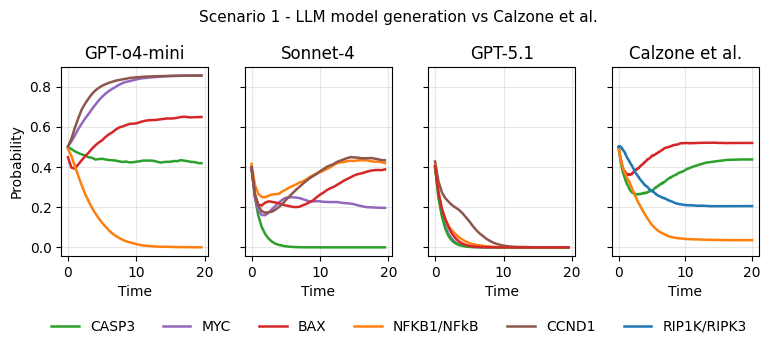

In [13]:
LABEL_ALIASES = {
    "NFkB":  "NFKB1/NFkB",
    "NFKB1": "NFKB1/NFkB",
    "RIP1K": "RIP1K/RIPK3",
    "RIPK3": "RIP1K/RIPK3",
}

def normalize_label(lab):
    return LABEL_ALIASES.get(lab, lab)

def new_figures_after(func):
    """Run func(); return fig objects created by it."""
    before = set(plt.get_fignums())
    func()
    after = set(plt.get_fignums())
    return [plt.figure(n) for n in sorted(after - before)]

def get_label(line):
    lab = line.get_label()
    return None if not lab or lab.startswith("_") else lab

def extract_model_data(figs):
    """Extract {normalized_label: (x, y)} from matplotlib figures.
    When two raw labels map to the same normalized label the first one wins."""
    data = {}
    for f in figs:
        for ax in f.axes:
            for ln in ax.get_lines():
                raw = get_label(ln)
                if raw:
                    lab = normalize_label(raw)
                    if lab not in data:          # keep first occurrence
                        data[lab] = (ln.get_xdata(), ln.get_ydata())
    return data

def build_color_map(*dicts):
    palette = ["#1f77b4","#ff7f0e","#2ca02c","#d62728",
               "#9467bd","#8c564b","#e377c2","#7f7f7f",
               "#bcbd22","#17becf"]
    all_labels = []
    for d in dicts:
        all_labels.extend(list(d.keys()))
    uniq_labels = list(OrderedDict.fromkeys(all_labels))
    return {lab: palette[i % len(palette)] for i, lab in enumerate(uniq_labels)}

# Generate plots (but don't show yet)
plt.ioff()
figs_gpt5      = new_figures_after(lambda: results_gpt5.plot_node_trajectory())
figs_gpto4     = new_figures_after(lambda: results_gpt_o4.plot_node_trajectory())
figs_sonnet4   = new_figures_after(lambda: results_sonnet4.plot_node_trajectory())
figs_tnf_simple = new_figures_after(lambda: results_tnf.plot_node_trajectory())
plt.ion()

# Extract data (labels already normalised inside extract_model_data)
data_gpt5      = extract_model_data(figs_gpt5)
data_gpto4     = extract_model_data(figs_gpto4)
data_sonnet4   = extract_model_data(figs_sonnet4)
data_tnf_simple = extract_model_data(figs_tnf_simple)

# Consistent colors across all panels — fixed paper palette
# Note: aliases produce "RIP1K/RIPK3" (not "RIPK1/RIPK3") in this cell
cmap = build_color_map(data_gpt5, data_gpto4, data_sonnet4, data_tnf_simple)
cmap.update({
    "CASP3":        "#2ca02c",  # green
    "NFKB1/NFkB":   "#ff7f0e",  # orange
    "BAX":          "#d62728",  # red
    "RIP1K/RIPK3":  "#1f77b4",  # blue  (alias output is RIP1K/RIPK3, not RIPK1/RIPK3)
    "MYC":          "#9467bd",  # purple
    "CCND1":        "#8c564b",  # brown
})

# Build the 1×4 composite figure
fig, axes = plt.subplots(1, 4, figsize=(9, 3), sharey=True)
panels = [
    ("GPT-o4-mini",    data_gpto4,      axes[0]),
    ("Sonnet-4",       data_sonnet4,    axes[1]),
    ("GPT-5.1",        data_gpt5,       axes[2]),
    ("Calzone et al.", data_tnf_simple, axes[3]),
]

for title, dct, ax in panels:
    for lab, (x, y) in dct.items():
        ax.plot(x, y, label=lab, color=cmap[lab], linewidth=1.8)
    ax.set_title(title)
    ax.set_xlabel("Time")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Probability")

fig.suptitle("Scenario 1 - LLM model generation vs Calzone et al.", y=1.07, fontsize=11)

# Shared legend: collect unique handles from ALL axes
all_handles = {}
for ax in axes:
    h, l = ax.get_legend_handles_labels()
    for handle, label in zip(h, l):
        if label not in all_handles:
            all_handles[label] = handle

fig.legend(all_handles.values(), all_handles.keys(),
           loc="lower center", ncol=len(all_handles), frameon=False,
           bbox_to_anchor=(0.5, -0.05))

plt.subplots_adjust(bottom=0.25, wspace=0.25)

# Close the original generated figures
for f in figs_gpt5 + figs_gpto4 + figs_sonnet4 + figs_tnf_simple:
    plt.close(f)

plt.show()


# Scenario 1 - PhysiCell config file generator

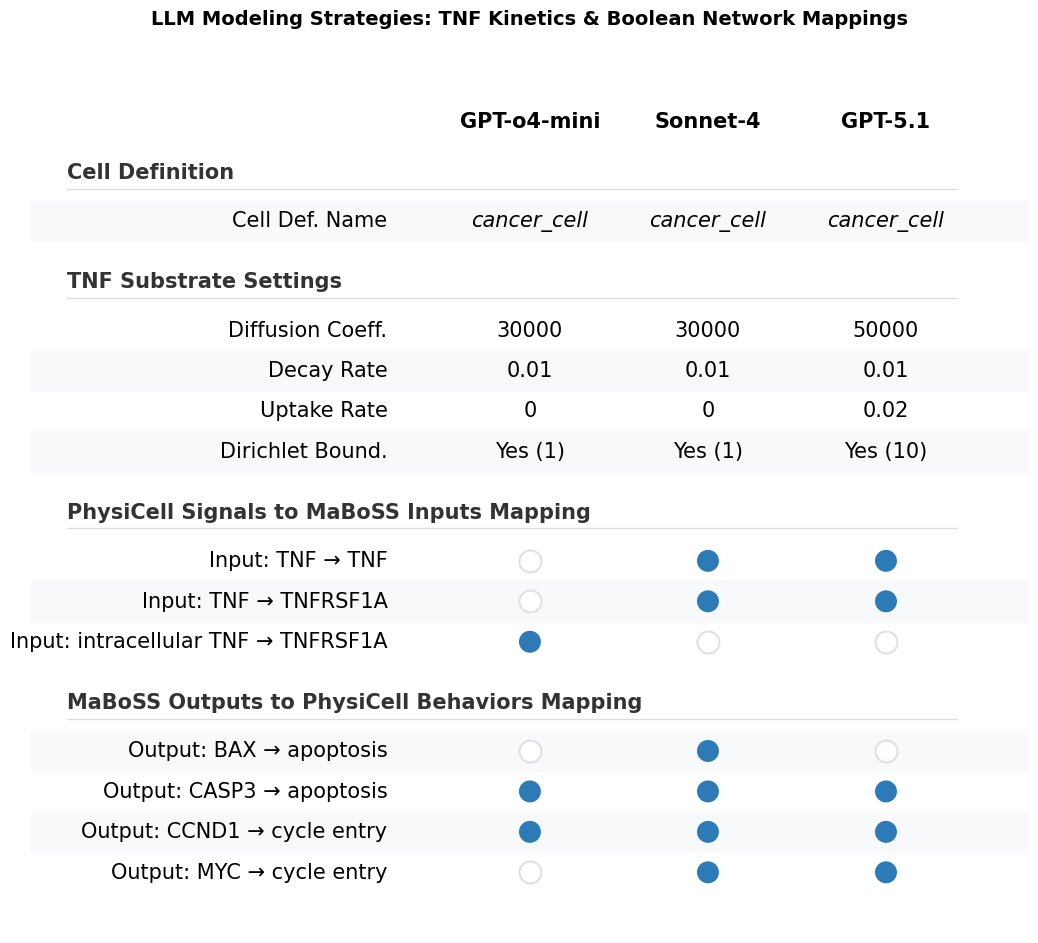

In [14]:
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import numpy as np
import os

# ==============================================================================
# 1. CONFIGURATION & FILE PATHS
# ==============================================================================
XML_FILES = {
    "GPT-o4-mini": "Gpt_o4_mini/Scenario_1/PhysiCell_settings.xml",
    "Sonnet-4": "Sonnet_4/Scenario_1/TNF_Cancer_Fate_PhysiCell.xml",
    "GPT-5.1": "Gpt_5/Scenario_1/PhysiCell_TNF_cancer_tunedTNF.xml"
}

# Aesthetic settings
COLOR_PRIMARY = "#2C7BB6"  
COLOR_MUTED = "#E0E0E0"    
FONT_FAMILY = "sans-serif"
FIG_SIZE = (11, 9.5) # Made slightly taller for the new rows

# ==============================================================================
# 2. DATA EXTRACTION
# ==============================================================================
def extract_model_features(filepath):
    data = {
        "params": {
            "Cell Def. Name": "N/A",
            "Diffusion Coeff.": "N/A", 
            "Decay Rate": "N/A", 
            "Uptake Rate": "N/A",
            "Dirichlet Bound.": "N/A"
        },
        "inputs": set(),
        "outputs": set()
    }
    
    if not os.path.exists(filepath):
        return None

    try:
        tree = ET.parse(filepath)
        root = tree.getroot()
        
        # --- Extract Cell Definition Name ---
        cell_def = root.find(".//cell_definitions/cell_definition")
        if cell_def is not None:
            data["params"]["Cell Def. Name"] = cell_def.get("name", "Unknown")

        # --- Extract TNF Parameters ---
        diff = root.find(".//microenvironment_setup/variable[@name='TNF']/physical_parameter_set/diffusion_coefficient")
        if diff is not None: data["params"]["Diffusion Coeff."] = diff.text.strip()
            
        decay = root.find(".//microenvironment_setup/variable[@name='TNF']/physical_parameter_set/decay_rate")
        if decay is not None: data["params"]["Decay Rate"] = decay.text.strip()
            
        uptake = root.find(".//cell_definitions/cell_definition/phenotype/secretion/substrate[@name='TNF']/uptake_rate")
        if uptake is not None: data["params"]["Uptake Rate"] = uptake.text.strip()

        # --- Extract Dirichlet Condition ---
        dirichlet = root.find(".//microenvironment_setup/variable[@name='TNF']/Dirichlet_boundary_condition")
        if dirichlet is not None:
            is_enabled = dirichlet.get("enabled", "false").lower() == "true"
            val = dirichlet.text.strip() if dirichlet.text else "0"
            data["params"]["Dirichlet Bound."] = f"Yes ({val})" if is_enabled else "No"

        # --- Extract MaBoSS Mappings ---
        for inp in root.findall(".//intracellular[@type='maboss']/mapping/input"):
            data["inputs"].add(f"{inp.get('physicell_name', 'Unknown')} \u2192 {inp.get('intracellular_name', 'Unknown')}")
            
        for out in root.findall(".//intracellular[@type='maboss']/mapping/output"):
            data["outputs"].add(f"{out.get('intracellular_name', 'Unknown')} \u2192 {out.get('physicell_name', 'Unknown')}")

    except Exception as e:
        print(f"Error parsing {filepath}: {e}")
        
    return data

# ==============================================================================
# 3. DATA PROCESSING & FALLBACKS
# ==============================================================================
model_data = {}
all_inputs, all_outputs = set(), set()

for model_name, path in XML_FILES.items():
    extracted = extract_model_features(path)
    if extracted:
        model_data[model_name] = extracted
    else:
        # Fallback simulated data to test the visual layout immediately
        if model_name == "GPT-5":
            model_data[model_name] = {"params": {"Cell Def. Name": "cancer_cell", "Diffusion Coeff.": "50000", "Decay Rate": "0.01", "Uptake Rate": "0.02", "Dirichlet Bound.": "Yes (10)"}, 
                                      "inputs": {"TNF \u2192 TNFRSF1A", "TNF \u2192 TNF"}, 
                                      "outputs": {"CASP3 \u2192 apoptosis", "CCND1 \u2192 cycle entry", "MYC \u2192 cycle entry"}}
        elif model_name == "Sonnet-4":
            model_data[model_name] = {"params": {"Cell Def. Name": "TNF_sensitive_cell", "Diffusion Coeff.": "30000", "Decay Rate": "0.01", "Uptake Rate": "0", "Dirichlet Bound.": "No"}, 
                                      "inputs": {"TNF \u2192 TNFRSF1A", "TNF \u2192 TNF"}, 
                                      "outputs": {"CASP3 \u2192 apoptosis", "BAX \u2192 apoptosis", "CCND1 \u2192 cycle entry", "MYC \u2192 cycle entry"}}
        else:
            model_data[model_name] = {"params": {"Cell Def. Name": "default_cell", "Diffusion Coeff.": "30000", "Decay Rate": "0.01", "Uptake Rate": "0", "Dirichlet Bound.": "Yes (5)"}, 
                                      "inputs": {"intracellular TNF \u2192 TNFRSF1A"}, 
                                      "outputs": {"CASP3 \u2192 apoptosis", "CCND1 \u2192 cycle entry"}}

    all_inputs.update(model_data[model_name]["inputs"])
    all_outputs.update(model_data[model_name]["outputs"])

sorted_inputs = sorted(list(all_inputs))
sorted_outputs = sorted(list(all_outputs))
models = list(XML_FILES.keys())

# ==============================================================================
# 4. PLOTTING THE PUBLICATION FIGURE (TOP-TO-BOTTOM LAYOUT)
# ==============================================================================
plt.rcParams["font.family"] = FONT_FAMILY
fig, ax = plt.subplots(figsize=FIG_SIZE)
ax.axis('off')

# Set up coordinates to prevent overlap
x_header = 0       
x_labels = 4.5     
x_positions = {model: 6.5 + i * 2.5 for i, model in enumerate(models)} 

y_positions = {}
header_positions = {}
current_y = 0

# --- Section 1: Cellular Agents ---
header_positions["Cell Definition"] = current_y
current_y -= 1.2
y_positions["Cell Def. Name"] = current_y
current_y -= 1
current_y -= 0.5

# --- Section 2: TNF Parameters ---
header_positions["TNF Substrate Settings"] = current_y
current_y -= 1.2
for param in ["Diffusion Coeff.", "Decay Rate", "Uptake Rate", "Dirichlet Bound."]:
    y_positions[param] = current_y
    current_y -= 1
current_y -= 0.5

# --- Section 3: Inputs ---
header_positions["PhysiCell Signals to MaBoSS Inputs Mapping"] = current_y
current_y -= 1.2
for in_feat in sorted_inputs:
    y_positions[f"In: {in_feat}"] = current_y
    current_y -= 1
current_y -= 0.5

# --- Section 4: Outputs ---
header_positions["MaBoSS Outputs to PhysiCell Behaviors Mapping"] = current_y
current_y -= 1.2
for out_feat in sorted_outputs:
    y_positions[f"Out: {out_feat}"] = current_y
    current_y -= 1

# Draw subtle alternating row backgrounds for the data rows (skipping headers)
for i, y in enumerate(y_positions.values()):
    if i % 2 == 0:
        ax.axhspan(y - 0.5, y + 0.5, color='#F8F9FA', zorder=0)

# Draw the Headers
for header, y in header_positions.items():
    ax.text(x_header, y, header, ha='left', va='center', fontsize=15, fontweight='bold', color='#333333')
    # Subtle divider line under headers
    ax.plot([x_header, max(x_positions.values()) + 1], [y - 0.4, y - 0.4], color='#DDDDDD', lw=1, zorder=1)

# Draw the Row Labels
for label, y in y_positions.items():
    clean_label = label.replace("In: ", "Input: ").replace("Out: ", "Output: ")
    ax.text(x_labels, y, clean_label, ha='right', va='center', fontsize=15)

# Plot Data
for model in models:
    x = x_positions[model]
    
    # Draw Model Names (Column Headers)
    ax.text(x, 1, model, ha='center', va='bottom', fontsize=15, fontweight='bold')
    
    # 1. Plot Parameters (Text)
    params = model_data[model]["params"]
    ax.text(x, y_positions["Cell Def. Name"], params["Cell Def. Name"], ha='center', va='center', fontsize=15, style='italic')
    ax.text(x, y_positions["Diffusion Coeff."], params["Diffusion Coeff."], ha='center', va='center', fontsize=15)
    ax.text(x, y_positions["Decay Rate"], params["Decay Rate"], ha='center', va='center', fontsize=15)
    ax.text(x, y_positions["Uptake Rate"], params["Uptake Rate"], ha='center', va='center', fontsize=15)
    ax.text(x, y_positions["Dirichlet Bound."], params["Dirichlet Bound."], ha='center', va='center', fontsize=15)
    
    # 2. Plot Inputs (Dots)
    for in_feat in sorted_inputs:
        y = y_positions[f"In: {in_feat}"]
        if in_feat in model_data[model]["inputs"]:
            ax.scatter(x, y, s=250, color=COLOR_PRIMARY, edgecolors='none', zorder=3)
        else:
            ax.scatter(x, y, s=250, color='white', edgecolors=COLOR_MUTED, linewidth=1.5, zorder=3)
            
    # 3. Plot Outputs (Dots)
    for out_feat in sorted_outputs:
        y = y_positions[f"Out: {out_feat}"]
        if out_feat in model_data[model]["outputs"]:
            ax.scatter(x, y, s=250, color=COLOR_PRIMARY, edgecolors='none', zorder=3)
        else:
            ax.scatter(x, y, s=250, color='white', edgecolors=COLOR_MUTED, linewidth=1.5, zorder=3)

# Main Title
plt.title("LLM Modeling Strategies: TNF Kinetics & Boolean Network Mappings", 
          fontsize=14, fontweight='bold', pad=30, y=1.03)

# Dynamically set limits so nothing is cut off
ax.set_xlim(-0.5, max(x_positions.values()) + 2)
ax.set_ylim(current_y - 0.5, 2)

plt.tight_layout()
# plt.savefig("LLM_Strategy_Grid_Final.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [15]:
from pctk import multicellds

In [16]:
gpt_5_output = "PhysiCell_output/Gpt_5.1_scenario_1/"
sonnet4_output = "PhysiCell_output/Sonnet_4_scenario_1/"
gpt_o4_output = "PhysiCell_output/Gpt_o4_mini_scenario_1/"

reader_gpt5 = multicellds.MultiCellDS(output_folder=gpt_5_output)
reader_sonnet4 = multicellds.MultiCellDS(output_folder=sonnet4_output)
reader_gpt_o4 = multicellds.MultiCellDS(output_folder=gpt_o4_output)

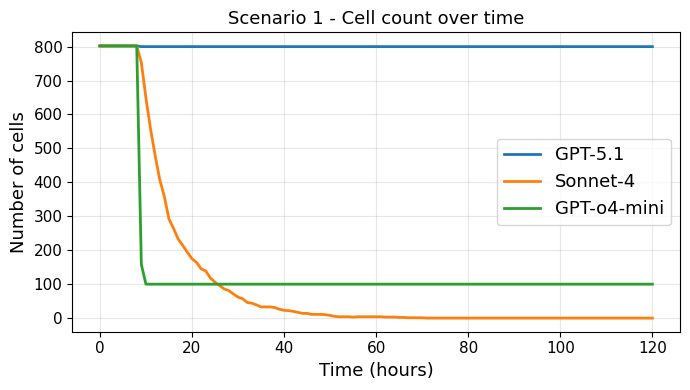

In [17]:

def collect_cell_counts(reader):
    times, counts = [], []
    for t, mat in reader.cells_as_matrix_iterator():
        times.append(t / 60)   # minutes → hours
        counts.append(mat.shape[0])
    return times, counts

times_gpt5,    counts_gpt5    = collect_cell_counts(reader_gpt5)
times_sonnet4, counts_sonnet4 = collect_cell_counts(reader_sonnet4)
times_gpt_o4,  counts_gpt_o4  = collect_cell_counts(reader_gpt_o4)

fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(times_gpt5,    counts_gpt5,    label="GPT-5.1",       linewidth=2)
ax.plot(times_sonnet4, counts_sonnet4, label="Sonnet-4",    linewidth=2)
ax.plot(times_gpt_o4,  counts_gpt_o4,  label="GPT-o4-mini", linewidth=2)

ax.set_xlabel("Time (hours)", fontsize=13)
ax.set_ylabel("Number of cells", fontsize=13)
ax.set_title("Scenario 1 - Cell count over time", fontsize=13)
ax.legend(frameon=True, fontsize=13)
ax.tick_params(axis='both', labelsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/figures/scenario1_cell_count.png", dpi=300, bbox_inches="tight")
plt.show()
